In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [2]:
%%duckdb

CREATE OR REPLACE TABLE trips_raw AS
SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
  USING SAMPLE 750000 ROWS
);

SELECT COUNT(*) as total_rows FROM trips_raw;

,total_rows
0,750000


# Veri Yükleme
S3'teki 23 milyon satırlık veriden RAM'i yormamak için rastgele 750.000 satırlık bir örneklem (sample) aldık.
Başlangıç ve bitiş zamanları arasındaki farkı bularak ana hedefimiz olan yolculuk süresini (`duration_min`) hesapladık.

In [3]:
%%duckdb
CREATE OR REPLACE TABLE trips_clean AS
SELECT *
FROM trips_raw
WHERE duration_min > 1 AND duration_min < 180
  AND "start station latitude" BETWEEN 40.48 AND 40.93
  AND "end station latitude" BETWEEN 40.48 AND 40.93
  AND "start station longitude" BETWEEN -74.26 AND -73.70
  AND "end station longitude" BETWEEN -74.26 AND -73.70;

SELECT 
    (SELECT COUNT(*) FROM trips_raw) as before_clean,
    (SELECT COUNT(*) FROM trips_clean) as after_clean;

,before_clean,after_clean
0,750000,744886


# Outlier Temizliği 
Modelimizi yanıltmaması için New York sınırları dışındaki bozuk GPS verilerini ve
1 dakikadan az veya 3 saatten fazla yolculuk sürelerini veriden temizledik.

In [4]:
%%duckdb
CREATE OR REPLACE TABLE trips_features AS
SELECT
    duration_min,

    hour(start_at) AS hour_of_day,

    CASE WHEN isodow(start_at) IN (6, 7) THEN 1 ELSE 0 END AS is_weekend,

    2 * 6371 * asin(sqrt(
        power(sin(radians("end station latitude" - "start station latitude") / 2), 2) +
        cos(radians("start station latitude")) * cos(radians("end station latitude")) *
        power(sin(radians("end station longitude" - "start station longitude") / 2), 2)
    )) AS haversine_km,

    ABS("end station latitude"  - "start station latitude")  * 111 +
    ABS("end station longitude" - "start station longitude") * 84  AS manhattan_km,

    CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber

FROM trips_clean
WHERE "start station latitude" IS NOT NULL
  AND "end station latitude"   IS NOT NULL;

,Count
0,744886


# Feature Engineering 
Modelin mantıklı tahmin yapabilmesi için ham veriden yeni öznitelikler ürettik: 
Kullanım saati, hafta sonu durumu, Haversine (kuş uçuşu) ve Manhattan (ızgara) mesafeleri. 

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = %duckdb SELECT * FROM trips_features;

X = df[['hour_of_day', 'is_weekend', 'haversine_km', 'manhattan_km', 'is_subscriber']]
y = df['duration_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

print(f"Eğitim (Train) set boyutu: {X_train.shape}")
print(f"Test set boyutu: {X_test.shape}")

Eğitim (Train) set boyutu: (595908, 5)
Test set boyutu: (148978, 5)


# Train/Test Split:
Veriyi %80 Eğitim (Train) ve %20 Test olarak böldük. 
Sıralamadan kaynaklı bir önyargı olmaması için bölerken veriyi tamamen karıştırdık (`shuffle=True`).

Bias (Intercept - Baz Süre): 15.15 dakika
------------------------------


,Özellik (Feature),Katsayı (Etkisi)
0,hour_of_day,0.042532
1,is_weekend,1.139102
2,haversine_km,4.872827
3,manhattan_km,-0.115659
4,is_subscriber,-11.974257


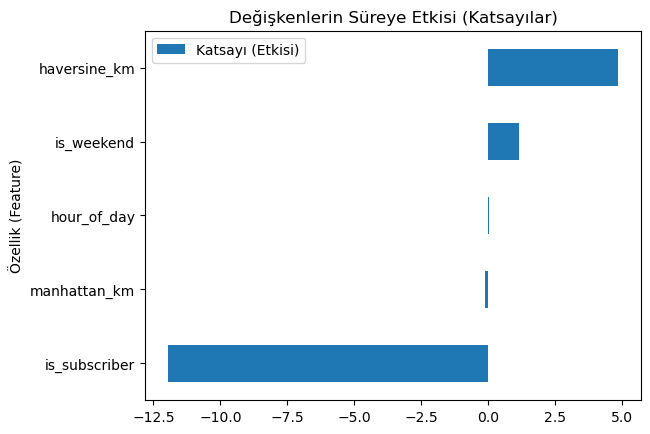

In [6]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from IPython.display import display

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

print(f"Bias (Intercept - Baz Süre): {model.intercept_:.2f} dakika")
print("-" * 30)

coef_df = pd.DataFrame({'Özellik (Feature)': X.columns, 'Katsayı (Etkisi)': model.coef_})
display(coef_df)

coef_df.sort_values('Katsayı (Etkisi)').plot(
    x='Özellik (Feature)', y='Katsayı (Etkisi)', 
    kind='barh', title='Değişkenlerin Süreye Etkisi (Katsayılar)'
)
plt.show()

# Model Eğitimi ve Bias: 
Doğrusal regresyon modelimizi eğittik. 
`fit_intercept=True` kullanarak modele bir "Bias" ekledik. 
Bu sayede model, mesafe 0 olsa bile kiralama-kilitleme gibi işlemlerin alacağı bazal süreyi hesaba kattı.

,Metrik,Train (Biased),Test (Unbiased)
0,RMSE (Ort. Hata-dk),9.552,9.580
1,MAE (Mutlak Hata-dk),4.664,4.686
2,R² (Açıklama Oranı),0.380,0.378


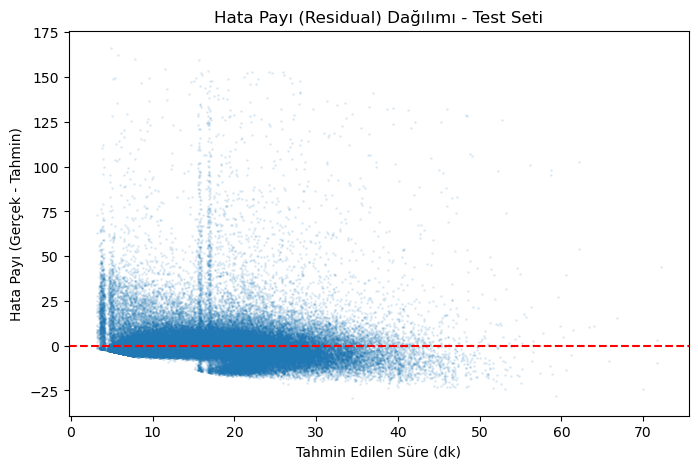

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

metrics = {
    'Metrik': ['RMSE (Ort. Hata-dk)', 'MAE (Mutlak Hata-dk)', 'R² (Açıklama Oranı)'],
    'Train (Biased)': [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_error(y_train, y_train_pred),
        r2_score(y_train, y_train_pred)
    ],
    'Test (Unbiased)': [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred),
        r2_score(y_test, y_test_pred)
    ]
}

display(pd.DataFrame(metrics).round(3))

residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.1, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Süre (dk)')
plt.ylabel('Hata Payı (Gerçek - Tahmin)')
plt.title('Hata Payı (Residual) Dağılımı - Test Seti')
plt.show()

# Model Değerlendirmesi
Eğittiğimiz modeli, (hiç görmediği) test seti üzerinde deneyerek 
tamamen tarafsız (unbiased) performans metriklerini (RMSE, MAE, R²) elde ettik. 
Hata (Residual) grafiği ile tahmin sapmalarını inceledik. 

In [8]:
from IPython.display import display

stations_df = %duckdb SELECT DISTINCT "start station name" as name, "start station latitude" as lat, "start station longitude" as lon FROM trips_clean WHERE "start station latitude" IS NOT NULL;

np.random.seed(42)

starts = stations_df.sample(10, replace=True).reset_index(drop=True)
ends = stations_df.sample(10, replace=True).reset_index(drop=True)

fictional_trips = pd.DataFrame({
    'start_name': starts['name'], 'end_name': ends['name'],
    'start_lat': starts['lat'], 'start_lon': starts['lon'],
    'end_lat': ends['lat'], 'end_lon': ends['lon'],
    'hour_of_day': np.random.randint(0, 24, 10), 
    'is_weekend': np.random.randint(0, 2, 10),   
    'is_subscriber': np.random.randint(0, 2, 10) 
})

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * (2 * np.arcsin(np.sqrt(a)))

fictional_trips['haversine_km'] = haversine(
    fictional_trips['start_lat'], fictional_trips['start_lon'],
    fictional_trips['end_lat'],   fictional_trips['end_lon']
)
fictional_trips['manhattan_km'] = (
    np.abs(fictional_trips['end_lat'] - fictional_trips['start_lat']) * 111 +
    np.abs(fictional_trips['end_lon'] - fictional_trips['start_lon']) * 84
)

X_fictional = fictional_trips[['hour_of_day', 'is_weekend', 'haversine_km', 'manhattan_km', 'is_subscriber']]
fictional_trips['predicted_duration'] = model.predict(X_fictional).clip(min=1).round(1)

display(fictional_trips[['start_name', 'end_name', 'hour_of_day', 'haversine_km', 'predicted_duration']])

,start_name,end_name,hour_of_day,haversine_km,predicted_duration
0,W 26 St & 8 Ave,Lefferts Pl & Franklin Ave,11,8.229679,43.6
1,W 13 St & 6 Ave,Cumberland St & Lafayette Ave,5,5.819354,44.0
2,Lewis Ave & Decatur St,9 Ave & W 14 St,1,8.867658,46.1
3,W 25 St & 6 Ave,W 20 St & 7 Ave,20,0.519819,7.6
4,Perry St & Bleecker St,E 2 St & Avenue B,0,2.306907,26.0
5,E 48 St & 5 Ave,Pacific St & Nevins St,11,8.002467,54.8
6,McKibbin St & Manhattan Ave,Cadman Plaza West & Montague St,21,4.113048,36.6
7,W 87 St & Amsterdam Ave,E 67 St & Lexington Ave,11,2.482738,27.4
8,11 Ave & W 59 St,Douglass St & 4 Ave,16,10.284983,65.8
9,E 33 St & 5 Ave,E 67 St & Park Ave,9,2.761646,28.5


# 10 Yeni Rota için Predict 
Modelin pratikte çalışıp çalışmadığını görmek için veri setinden rastgele 10 kalkış ve varış noktası seçtik.
Özelliklerini hesaplayıp bu 10 yeni rota için süre tahmini yaptırdık.

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [9]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


In [10]:
%%duckdb -o df_raw

SELECT *
FROM (
    SELECT
        gender,
        "birth year"              AS birth_year,
        "start station latitude"  AS start_lat,
        "start station longitude" AS start_lng,
        "end station latitude"    AS end_lat,
        "end station longitude"   AS end_lng,
        strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
        strptime(stoptime,  ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    WHERE gender IN (1, 2)
) USING SAMPLE 500000 ROWS;

,gender,birth_year,start_lat,start_lng,end_lat,end_lng,start_at,stop_at
0,2,1989.0,40.734232,-73.986923,40.724677,-73.987834,2016-06-04 11:29:43,2016-06-04 11:36:56
1,1,1987.0,40.722293,-73.991475,40.707678,-73.940162,2016-12-13 21:20:09,2016-12-13 21:44:53
2,1,1974.0,40.751396,-74.005226,40.750585,-73.994685,2016-11-09 17:11:53,2016-11-09 17:18:19
3,1,1993.0,40.738177,-73.977387,40.743116,-73.982154,2016-10-12 08:43:46,2016-10-12 08:47:29
4,1,1972.0,40.737815,-73.999947,40.732233,-73.988900,2016-06-26 00:38:42,2016-06-26 00:44:49
...,...,...,...,...,...,...,...,...
499995,2,1987.0,40.716250,-74.009106,40.747348,-73.997236,2016-11-19 13:22:15,2016-11-19 13:39:16
499996,2,1984.0,40.773407,-73.977825,40.765909,-73.976342,2016-09-09 06:55:12,2016-09-09 07:02:28
499997,1,1991.0,40.747804,-73.973442,40.755103,-73.974987,2016-10-18 08:05:51,2016-10-18 08:11:39
499998,1,1982.0,40.754557,-73.965930,40.750664,-74.001768,2015-08-04 00:31:59,2015-08-04 00:52:58


In [11]:
%%duckdb -o df_calc

SELECT
    gender,
    year(start_at) - birth_year AS age,
    date_diff('minute', start_at, stop_at) AS duration_min,
    -- Haversine: iki koordinat arası kuş uçuşu mesafe (km), Dünya yarıçapı = 6371
    2 * 6371 * asin(sqrt(
        power(sin(radians(end_lat - start_lat) / 2), 2) +
        cos(radians(start_lat)) * cos(radians(end_lat)) *
        power(sin(radians(end_lng - start_lng) / 2), 2)
    )) AS distance_km
FROM df_raw
WHERE start_lat IS NOT NULL AND end_lat IS NOT NULL
  AND birth_year IS NOT NULL;

,gender,age,duration_min,distance_km
0,2,27.0,7,1.065215
1,1,29.0,24,4.620078
2,1,42.0,7,0.892512
3,1,23.0,4,0.680373
4,1,44.0,6,1.118778
...,...,...,...,...
499981,2,29.0,17,3.599707
499982,2,32.0,7,0.842969
499983,1,25.0,6,0.821974
499984,1,33.0,21,3.049688


In [12]:
%%duckdb -o df_speed

SELECT
    gender,
    age,
    distance_km,
    duration_min,
    distance_km / (duration_min / 60.0) AS speed_kmh   -- km / saat
FROM df_calc
WHERE duration_min BETWEEN 1 AND 240                    -- negatif/sıfır ve 4 saatten uzun yolculukları at
  AND distance_km > 0.1                                  -- aynı istasyona dönüş (mesafe ~0) at
  AND age BETWEEN 10 AND 90                               -- hatalı doğum yıllarını (1885 vb.) at
  AND distance_km / (duration_min / 60.0) BETWEEN 2 AND 40;  -- gerçekçi olmayan hızları at

,gender,age,distance_km,duration_min,speed_kmh
0,2,27.0,1.065215,7,9.130410
1,1,29.0,4.620078,24,11.550194
2,1,42.0,0.892512,7,7.650104
3,1,23.0,0.680373,4,10.205600
4,1,44.0,1.118778,6,11.187783
...,...,...,...,...,...
485949,2,29.0,3.599707,17,12.704847
485950,2,32.0,0.842969,7,7.225448
485951,1,25.0,0.821974,6,8.219742
485952,1,33.0,3.049688,21,8.713396


In [13]:
print("Satır sayısı:", df_speed.shape[0])
print("\nHız özeti (km/saat), cinsiyete göre:")
print(df_speed.groupby("gender")["speed_kmh"].agg(["count", "mean", "std", "min", "max"]).round(2))

Satır sayısı: 485954

Hız özeti (km/saat), cinsiyete göre:
         count  mean   std  min    max
gender                                
1       369782  9.68  2.84  2.0  39.23
2       116172  8.70  2.54  2.0  27.80


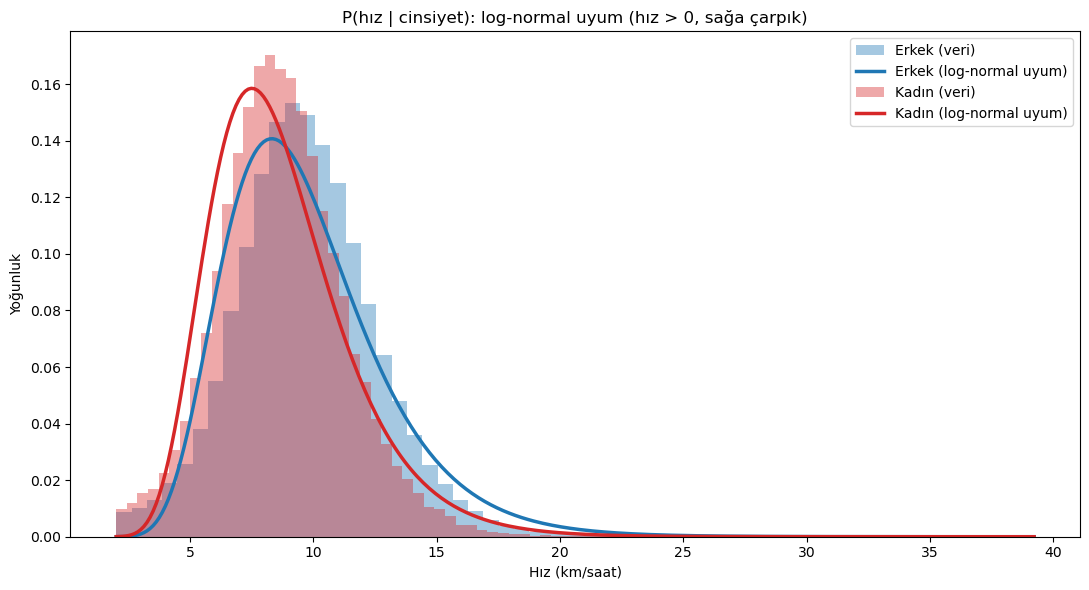

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(11, 6))

x = np.linspace(max(0.01, df_speed["speed_kmh"].min()),
                df_speed["speed_kmh"].max(), 300)

for g, etiket, renk in [(1, "Erkek", "tab:blue"), (2, "Kadın", "tab:red")]:
    veri = df_speed[df_speed["gender"] == g]["speed_kmh"]

    plt.hist(veri, bins=60, density=True, alpha=0.4, color=renk, label=f"{etiket} (veri)")

    shape, loc, scale = stats.lognorm.fit(veri, floc=0)
    plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale),
             color=renk, lw=2.5, label=f"{etiket} (log-normal uyum)")

plt.title("P(hız | cinsiyet): log-normal uyum (hız > 0, sağa çarpık)")
plt.xlabel("Hız (km/saat)")
plt.ylabel("Yoğunluk")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

X = df_speed[["speed_kmh"]]
y = df_speed["gender"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train = pd.concat([X_train, y_train], axis=1)

params = {}
for g in [1, 2]:
    grup = train[train["gender"] == g]["speed_kmh"]
    log_grup = np.log(grup)          

    params[g] = {
        "prior": len(grup) / len(train),
        "mu":    log_grup.mean(),    
        "var":   log_grup.var(),     
    }
    p = params[g]
    print(f"gender={g}: prior={p['prior']:.3f} | mu(log)={p['mu']:.2f} | var(log)={p['var']:.2f}")

gender=1: prior=0.761 | mu(log)=2.22 | var(log)=0.10
gender=2: prior=0.239 | mu(log)=2.12 | var(log)=0.10


In [16]:
import math

def log_gauss(x, mu, var):
    return -0.5 * math.log(2 * math.pi * var) - ((x - mu) ** 2) / (2 * var)

def predict(speed):
    log_speed = math.log(speed)     
    skorlar = {
        g: math.log(p["prior"]) + log_gauss(log_speed, p["mu"], p["var"])
        for g, p in params.items()
    }
    return max(skorlar, key=skorlar.get)

In [17]:
y_pred = X_test["speed_kmh"].apply(predict)

accuracy  = (y_pred == y_test).mean()
base_rate = (y_test == 1).mean()   

print(f"Accuracy        : %{accuracy * 100:.2f}")
print(f"Base-rate       : %{base_rate * 100:.2f}   (hep 'erkek' deseydik)")
print(f"Lift (katkı)    : %{(accuracy - base_rate) * 100:.2f}\n")

print("Karışıklık matrisi:")
print(pd.crosstab(y_test, y_pred, rownames=["Gerçek"], colnames=["Tahmin"]), "\n")

print("Sınıf bazında recall (gerçekte o cinsiyet olanları yakalama oranı):")
for g in [1, 2]:
    m = (y_test == g)
    print(f"  gender={g}: %{(y_pred[m] == g).mean() * 100:.2f}")

Accuracy        : %76.02
Base-rate       : %76.09   (hep 'erkek' deseydik)
Lift (katkı)    : %-0.07

Karışıklık matrisi:
Tahmin      1    2
Gerçek            
1       73857  100
2       23206   28 

Sınıf bazında recall (gerçekte o cinsiyet olanları yakalama oranı):
  gender=1: %99.86
  gender=2: %0.12


# Problem 2: Naive Bayes'i Sürekli Değişkene Genişletme

Hızdan cinsiyet tahmini. Hız sürekli olduğu için `P(hız|cinsiyet)`'i dağılımla modelledik.

- **Hücre 1:** Veriyi yükledik (cinsiyeti örneklemeden önce süzdük).
- **Hücre 2:** Mesafeyi (haversine) ve süreyi türettik.
- **Hücre 3:** Hızı hesapladık + bozuk kayıtları temizledik.
- **Hücre 4:** Sağlık kontrolü yaptık (sayı, ortalama, sınırlar).
- **Hücre 5:** Part 2 → histogram + eğri uydurduk. Normal dağılım (-∞, +∞) aralığında
  tanımlı olduğu için negatif hızlara olasılık atıyor ve veri sağa çarpık olduğundan
  iyi uymuyor. Bu yüzden yalnızca x > 0 için tanımlı ve sağa çarpık olan
  **log-normal dağılımı** seçtik.
- **Hücre 6:** Train/test böldük; her cinsiyet için prior ile log-normal
  parametrelerini (log-uzayında μ, σ²) öğrendik.
- **Hücre 7:** Tahmin fonksiyonunu yazdık (log-normal Naive Bayes; hızı log-uzayına
  çevirip normal yoğunluğun logunu kullanıyoruz).
- **Hücre 8:** Test ettik (accuracy vs base-rate, recall, karışıklık matrisi).
- **Hücre 9:** Sonucu yorumladık.

**Sonuç:** Accuracy (%76.02) ≈ base-rate (%76.09), kadın recall %0.12 → model
neredeyse herkese "erkek" diyor. Hız dağılımları örtüşüyor; log-normal geçişi
modeli tutarlı yaptı ama hız tek başına cinsiyet için zayıf bir özellik.